# Zero shot evaluation of MDA HACL library
Eg. in silico saturation mutagenesis.

These data should be used in complement to actual saturation mut. A high score here that did not perform particularly well as in vitro may indicate a mutation that requirs higher order interaction to function

In [19]:
from aide_predict.bespoke_models import MSATransformerLikelihoodWrapper
from aide_predict.utils.data_structures import ProteinSequences, ProteinSequence, ProteinSequencesOnFile
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [2]:
msa = ProteinSequencesOnFile.from_fasta('mda_hacl_msa.a2m')
msa

ProteinSequencesOnFile(file='mda_hacl_msa.a2m', count=5126, aligned=True, fixed_length=False)

In [3]:
wt = ProteinSequence("MAQLTGEQIIARSLKTQGIDKIFGVVGIPVTGIASACQAEGLTYTGMRHEMPAAYAAQAVSFIGPRMGAALAVSGPGVLNAVAAFANAWSNRWPMLLLGGSYEQSGHSMGFFQEADQLTPLRPFAKYAERVEMIERIPIYIAEAVKKALYGTPGPSYLDLPGDIIAGSVDEEKVQWAERVPDPRRMQADPRDIEAAIAALKTAEQPLIIIGKGIAYSRAEQEMRAFVEKTGLPFLAMPMAKGILPDDHPQAAAAARSFILQNADMVLLMGARMNWMLHFGLPPRLKQGVRVIQLDINPEEIGVNVPTEVAMVGDAKATLGQMLDVLDREPWTFPQDSEWLAQVKAEARTNQEAVESMMQEESNPIGYYRALRSISEAMPKDMVLVAEGASTMDISRSVINNFQPRTRLDAGSFGSMGLGHGFAIGAAVETGKHVLCLQGDGAFGFAGTECEVAVRYNLPITWVVFNNGGIGGHKAELFEGDQKPVGGMSLNARYDIMMQGLGGMGILAESSADLDAALQKALAHNGPSLINVPLDPEARRKPQKFGWLTSTSGTQASASAVPKND",
                     id='wt')

In [5]:
len(wt) == msa.width

True

In [6]:
library = wt.saturation_mutagenesis()
library

ProteinSequences(count=10735, aligned=True, fixed_length=True)

In [9]:
model = MSATransformerLikelihoodWrapper(
    metadata_folder='tmp',
    pool=True,
    device='mps',
    marginal_method='wildtype_marginal',
    wt=wt
)
model.fit(msa)

This model class did not implement check_metadata. If the model requires anything other than raw sequences to be fit, this is unexpected.


MSATransformerLikelihoodWrapper(device='mps', metadata_folder='tmp',
                                wt=ProteinSequence(id=None, seq='MAQLTGEQIIARSLKTQGID...'))

In [10]:
predictions = model.predict(library)

MSA batches: 166it [15:20,  5.55s/it]0<?, ?it/s]
Sequences: 100%|██████████| 1/1 [15:20<00:00, 920.58s/it]


(10735, 1)
None


In [11]:
predictions

array([[-7.4518653 ],
       [-7.9327268 ],
       [-7.55476408],
       ...,
       [-3.66822949],
       [-3.70989533],
       [-5.48701924]])

In [15]:
data = pd.DataFrame({
    'variant': list(library.get_id_mapping().keys()),
    'prediction': predictions.flatten()
})

In [16]:
data.to_csv('predictions.csv')

## How do these compare to the chosen positions?

In [17]:
data['position'] = data['variant'].apply(lambda x: int(x[1:-1]))

In [20]:
y = data['prediction'].values
scaler = StandardScaler()
y = scaler.fit_transform(y.reshape(-1, 1)).flatten()
data['prediction'] = y


In [36]:
chosen_positions = [25,26,27,28,29,30,31,73,111,112,113,173,253,254,256,257,275,276,329,354,359,360,387,388,389,390,391,392,393,396,397,410,413,414,415,416,417,421,422,441,442,445,470,471,484,485,486,488,540,541,542,543,544,545,546,551,556,557,558,559,560,561,562,563]

In [37]:
data['chosen'] = data['position'].apply(lambda x: x in chosen_positions)

In [39]:
data['position'] = data['position'].apply(str)

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
sns.set_style("whitegrid")
sns.set_context("talk")

/var/folders/4b/6yg7r65x0152cnhzpgzdhmvrjcvswz/T/ipykernel_75050/4263987090.py:17: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)


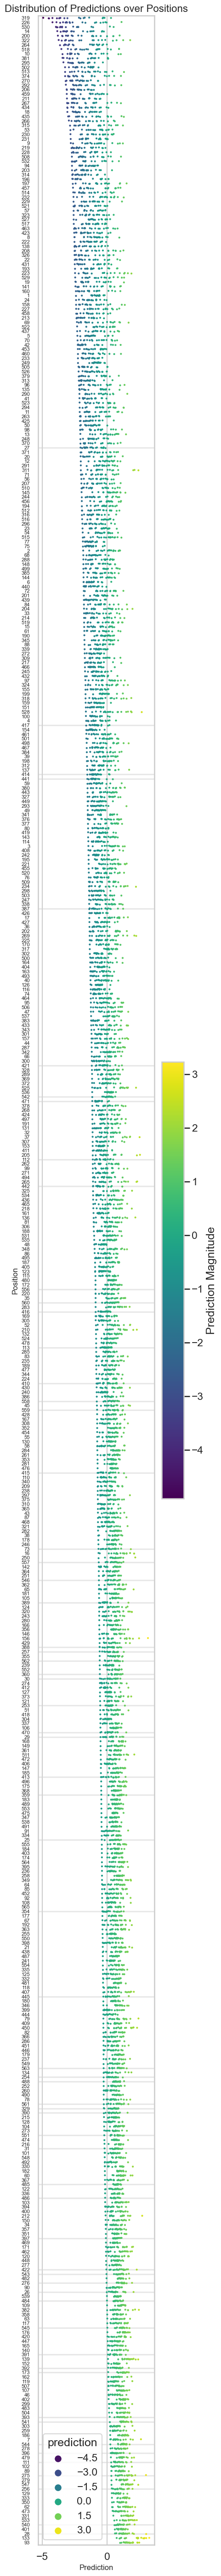

In [46]:
df_sorted = data.sort_values('prediction')

# Calculate the figure height based on the number of unique positions
n_positions = df_sorted['position'].nunique()
fig_height = max(10, n_positions * 0.1)  # Adjust the multiplier as needed

# Create the figure and axes
fig, ax = plt.subplots(figsize=(5, fig_height))

# Create the swarm plot
sns.stripplot(x='prediction', y='position', data=df_sorted, size=3, orient='h', hue='prediction', palette='viridis', ax=ax)

# Customize the plot
ax.set_title('Distribution of Predictions over Positions', fontsize=16)
ax.set_xlabel('Prediction', fontsize=12)
ax.set_ylabel('Position', fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

# Add a colorbar to show the magnitude of predictions
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=data['prediction'].min(), vmax=data['prediction'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Prediction Magnitude')

chosen_positions = df_sorted[df_sorted['chosen']]['position'].unique()
for pos in chosen_positions:
    ax.axhline(y=pos, color='lightgrey', alpha=0.5, zorder=1)

# Adjust layout and display the plot
plt.tight_layout()
plt.savefig('predictions.png', dpi=300, bbox_inches='tight')

In [43]:
df_sorted.to_csv('predictions.csv')